# Master BigData UCM 2023

## 1. Datos vehículos a la venta 2016 en UK

Propósito:

- Facilitar la lectura del .csv que contiene los datos de este ejemplo



In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
import plotnine
from plotnine import *

### Carga de datos

Este dataset tiene ya 7 años pero sigue siendo válido para nuestro propósito. 

La principal ventaja es que tiene una variale de grupo (o "factor") creada en español (la variable "Tipo") para facilitar los gráficos por tipo de vehículo.

In [3]:
df= pd.read_pickle("datos_vehiculos_2016.pkl")

In [4]:
df.shape

(4490, 20)

In [5]:
df.describe(include = 'all')

,Manufacturer,Model,EngineCapacity,FuelType,MetricUrbanCold,MetricExtraUrban,MetricCombined,ImperialUrbanCold,ImperialExtraUrban,ImperialCombined,CO2gkm,FuelCost12000Miles,EuroStandard,NoiseLeveldBA,EmissionsCOmgkm,THCEmissionsmgkm,EmissionsNOxmgkm,THC+NOxEmissionsmgkm,ParticulatesNo_mgkm,Tipo
count,4490,4490,4490.000000,4490,4459.000000,4459.000000,4490.000000,4459.000000,4459.000000,4490.000000,4490.000000,4490.000000,4490.0,4490.000000,4490.000000,2230.000000,4490.000000,2289.000000,2293.000000,4490
unique,44,450,NaN,7,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3
top,BMW,Coupe,NaN,Diesel,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Diesel
freq,607,260,NaN,2274,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2274
mean,NaN,NaN,1991.111804,NaN,6.925252,4.790491,5.549042,45.364230,62.014891,55.120445,135.823163,1086.980401,6.0,71.302249,260.113007,41.636726,37.138886,80.458934,0.300039,NaN
std,NaN,NaN,828.057573,NaN,2.800404,1.224893,1.794549,12.962089,12.771535,15.869631,39.732306,348.519954,0.0,1.969812,143.096498,14.819350,18.805169,22.962894,0.331194,NaN
min,NaN,NaN,647.000000,NaN,0.000000,0.000000,0.600000,0.000000,0.000000,17.300000,13.000000,117.000000,6.0,66.000000,10.000000,4.000000,1.000000,19.000000,0.000000,NaN
25%,NaN,NaN,1499.000000,NaN,5.200000,4.000000,4.400000,36.700000,53.300000,46.300000,112.000000,867.000000,6.0,70.000000,156.000000,33.000000,23.000000,66.000000,0.060000,NaN
50%,NaN,NaN,1968.000000,NaN,6.100000,4.500000,5.100000,46.300000,62.800000,55.400000,127.000000,999.500000,6.0,71.000000,230.000000,41.000000,36.000000,81.000000,0.180000,NaN
75%,NaN,NaN,1997.000000,NaN,7.700000,5.300000,6.100000,54.300000,70.600000,64.200000,149.000000,1202.000000,6.0,73.000000,329.000000,49.000000,52.000000,97.000000,0.480000,NaN


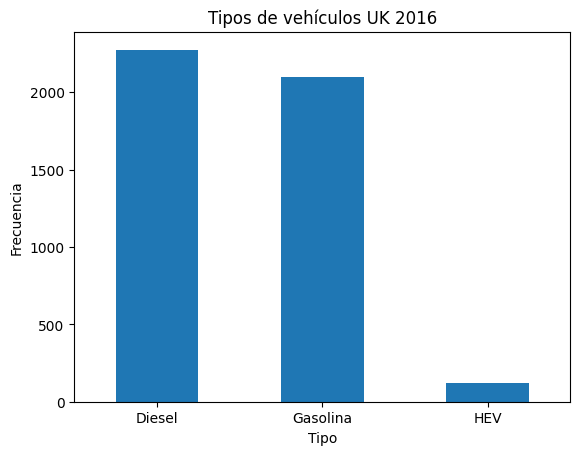

In [6]:
count_classes = df['Tipo'].value_counts(sort = True)
count_classes.plot(kind = 'bar', rot=0)
plt.title("Tipos de vehículos UK 2016")
plt.xlabel("Tipo")
plt.ylabel("Frecuencia");

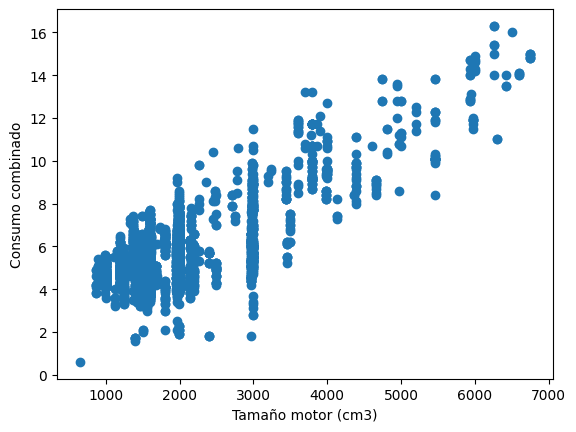

In [7]:
plt.scatter(df['EngineCapacity'], 
            df['MetricCombined'])

plt.xlabel('Tamaño motor (cm3)')
plt.ylabel('Consumo combinado')
plt.show()

# 2. Visualizaciones con ggplot

Además del contenido recogido en la docu. teórica, es aconsejable seguir este excelente (y práctico) tutorial:

https://realpython.com/ggplot-python/


## 2.1 Scatterplot dataset vehículos



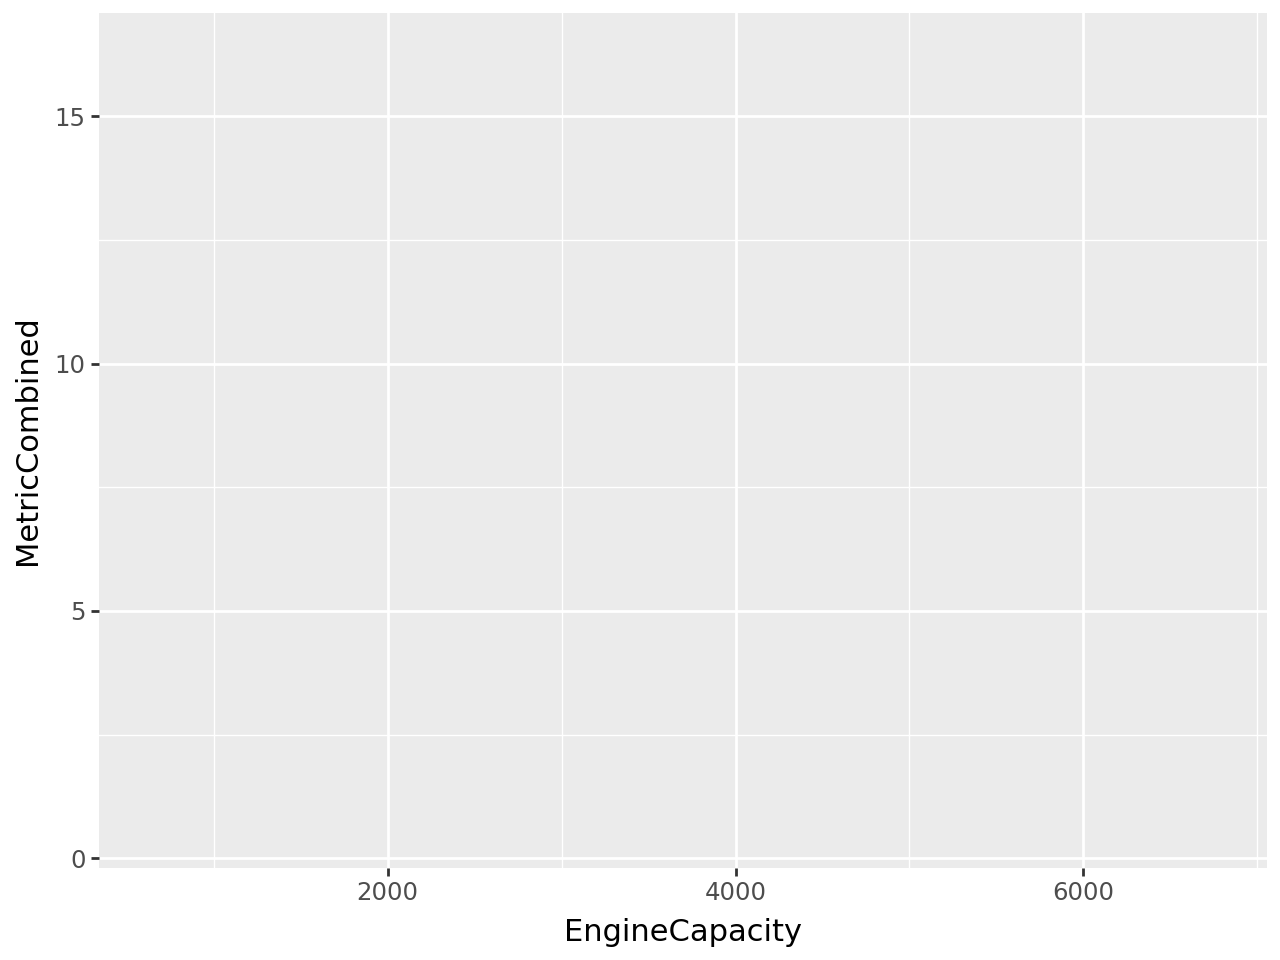

In [8]:
(
ggplot(df) +
    aes(x = 'EngineCapacity', 
        y = 'MetricCombined')
)

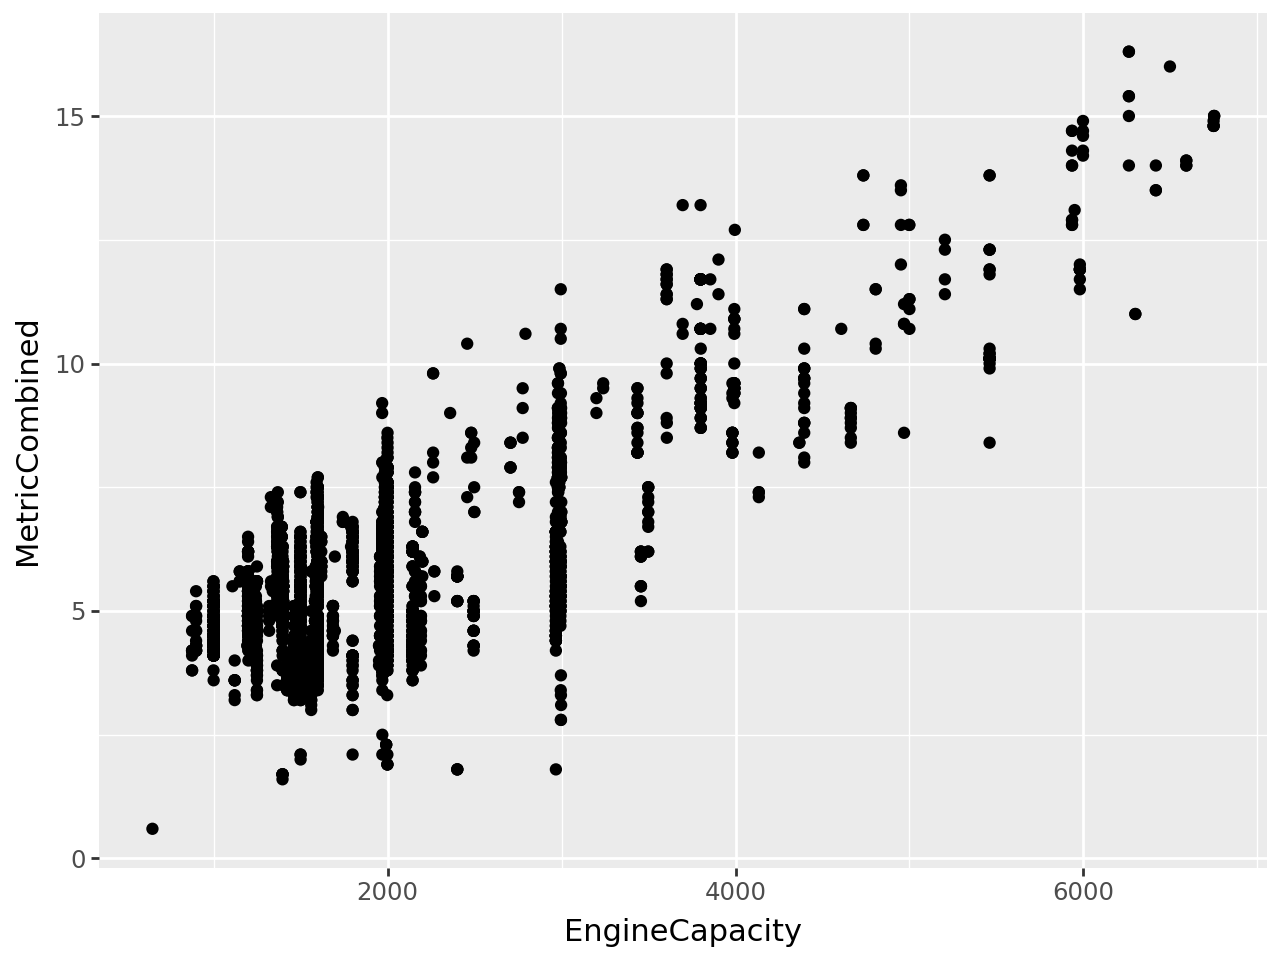

In [9]:
(
    ggplot(df)  # What data to use
    + aes(x = 'EngineCapacity', 
          y = 'MetricCombined')  # What variable to use
    + geom_point()   # Geometric object to use for drawing
)

In [10]:
mi_grafico = (
ggplot(df) +
    aes(x = 'EngineCapacity', 
          y = 'MetricCombined')
)

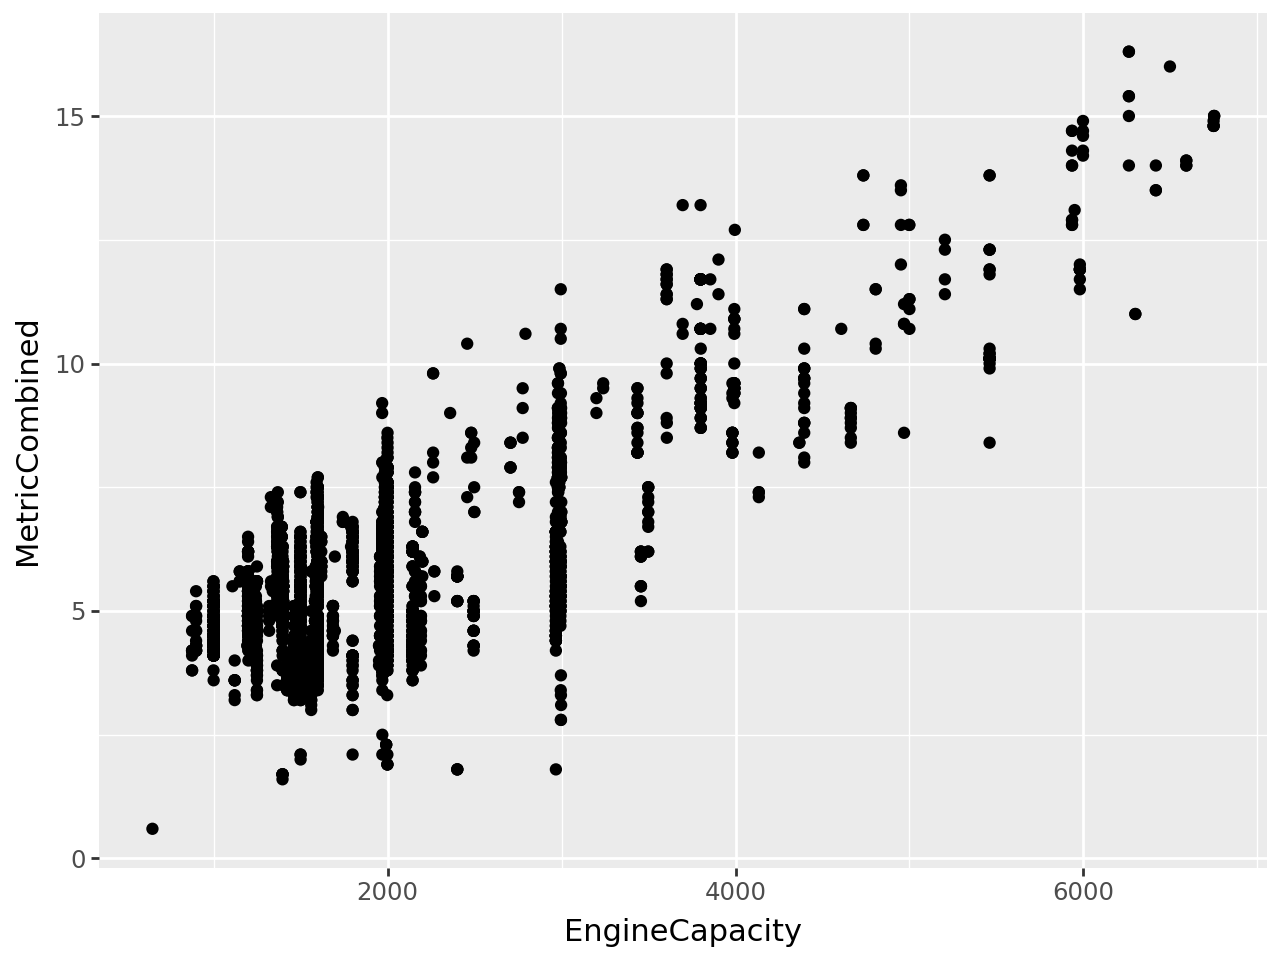

In [11]:
mi_grafico + geom_point()

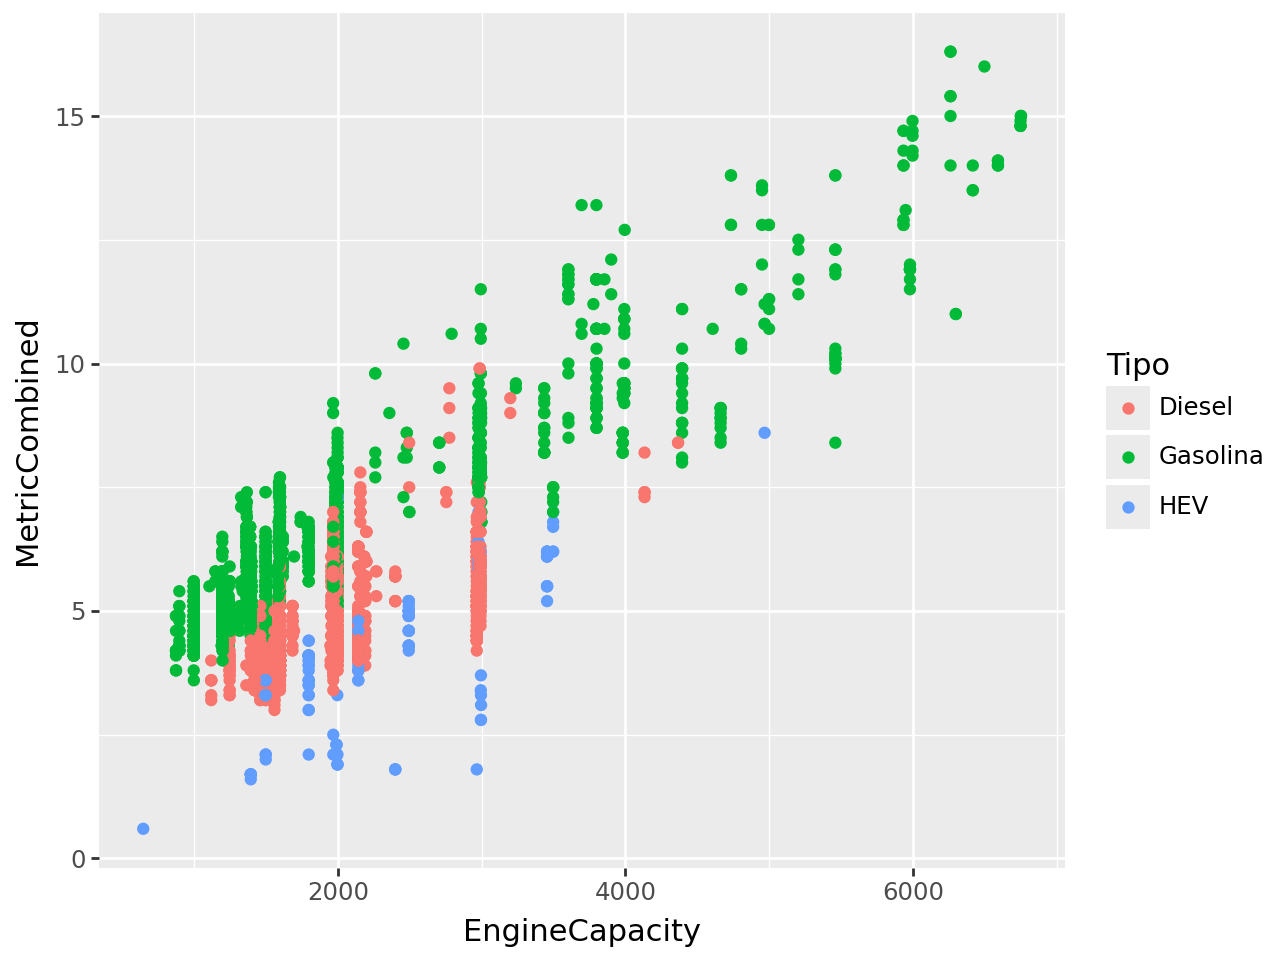

In [12]:
(
    ggplot(df)  # What data to use
    + aes(x = 'EngineCapacity', 
          y = 'MetricCombined',
          color = 'Tipo')  # What variable to use
    + geom_point()   # Geometric object to use for drawing
)

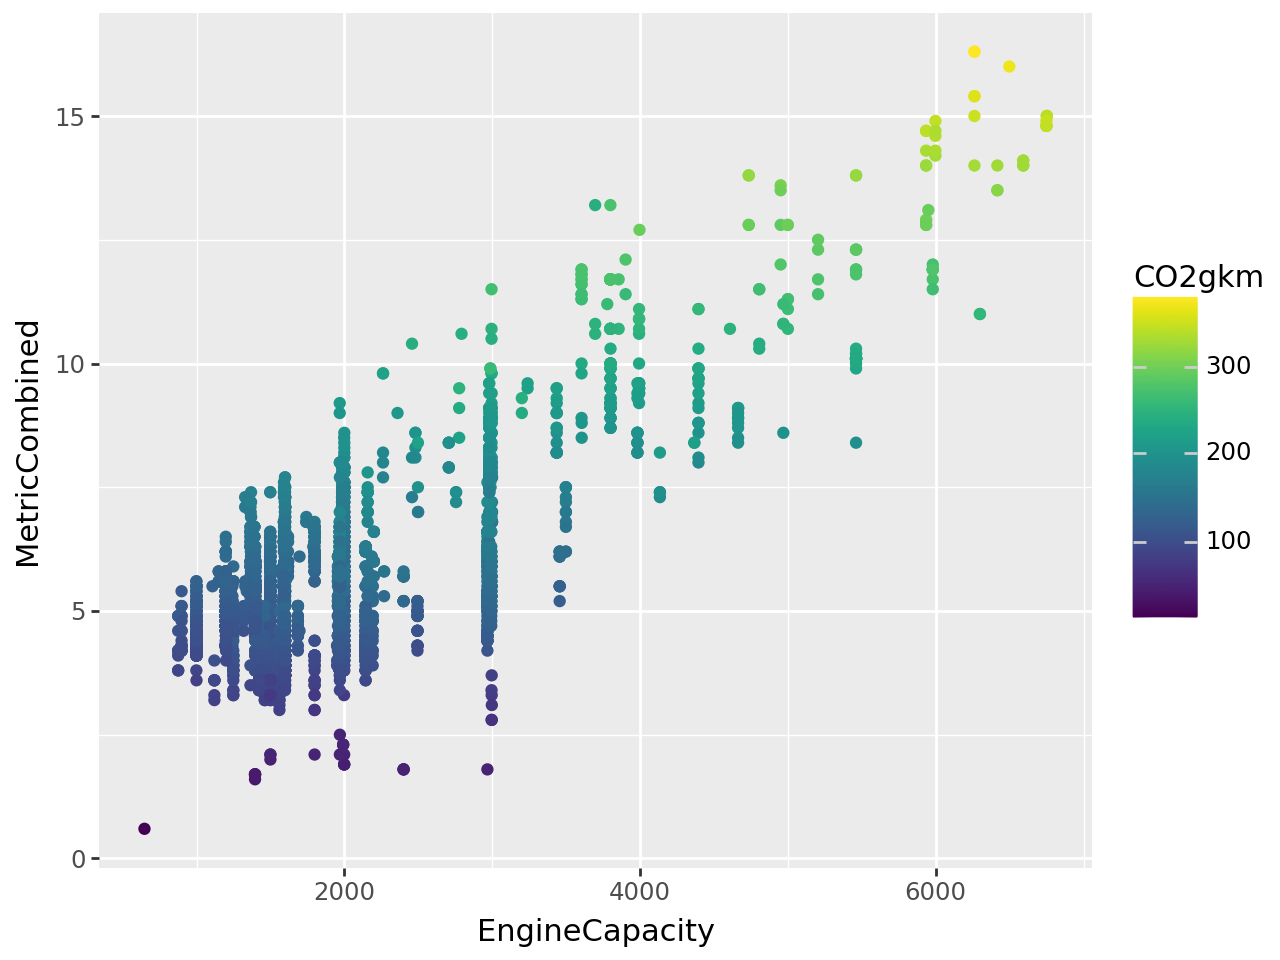

In [13]:
(
    ggplot(df)  # What data to use
    + aes(x = 'EngineCapacity', 
          y = 'MetricCombined',
         color = 'CO2gkm')  # What variable to use
    +  geom_point()   # Geometric object to use for drawing
)

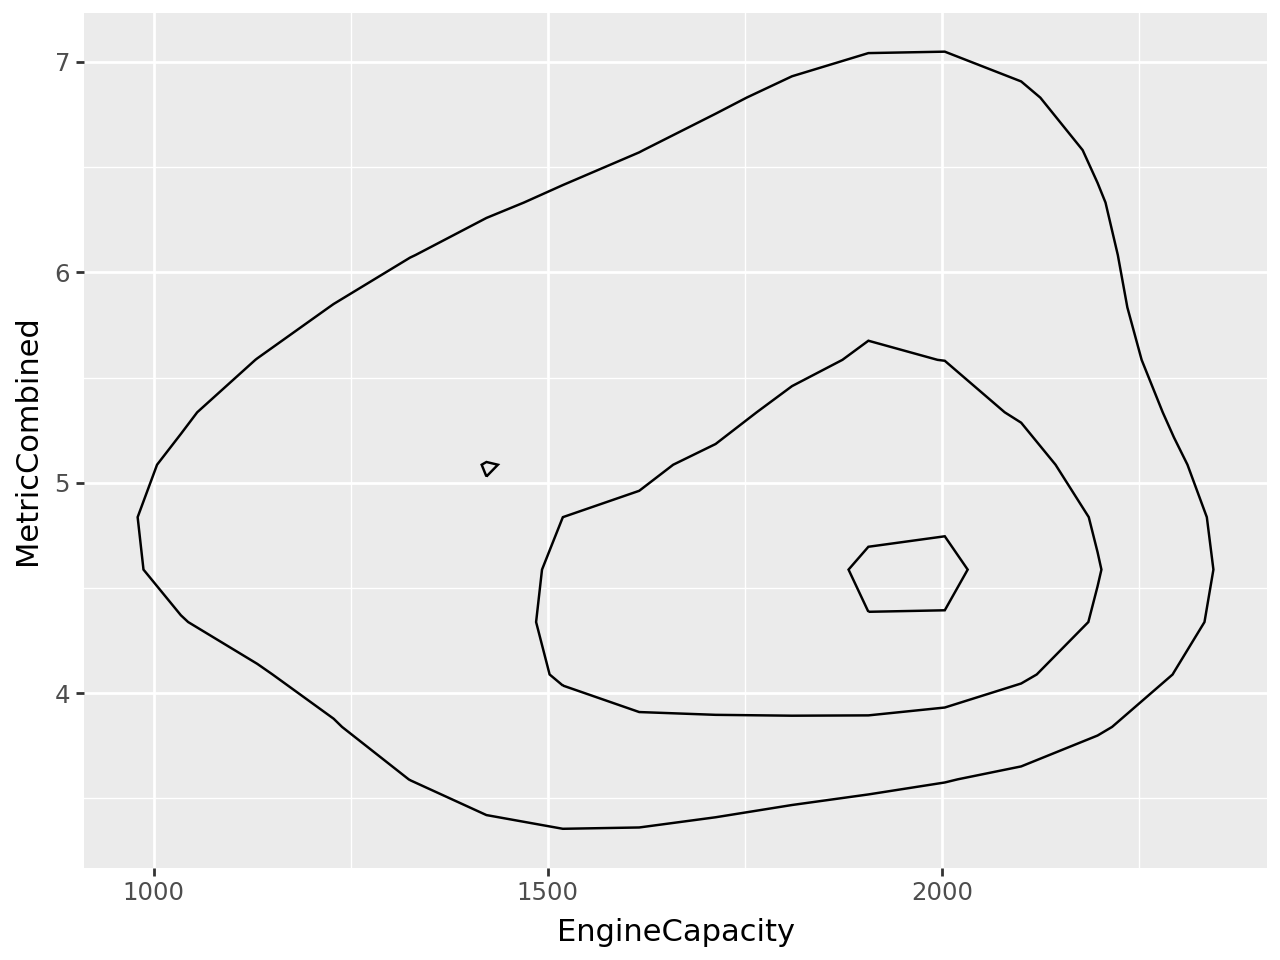

In [14]:
(
    ggplot(df)  # What data to use
    + aes(x = 'EngineCapacity', 
          y = 'MetricCombined',
         color = 'CO2gkm')  # What variable to use
    +  geom_density_2d()   # Geometric object to use for drawing
)

In [15]:
!pip install scikit-learn
!pip install scikit-misc

In [16]:
import sklearn
import skmisc

/home/pedro/Escritorio/UCM_2026/entorno_junio/lib/python3.12/site-packages/plotnine/stats/smoothers.py:342: PlotnineWarning: Confidence intervals are not yet implemented for lowess smoothings.


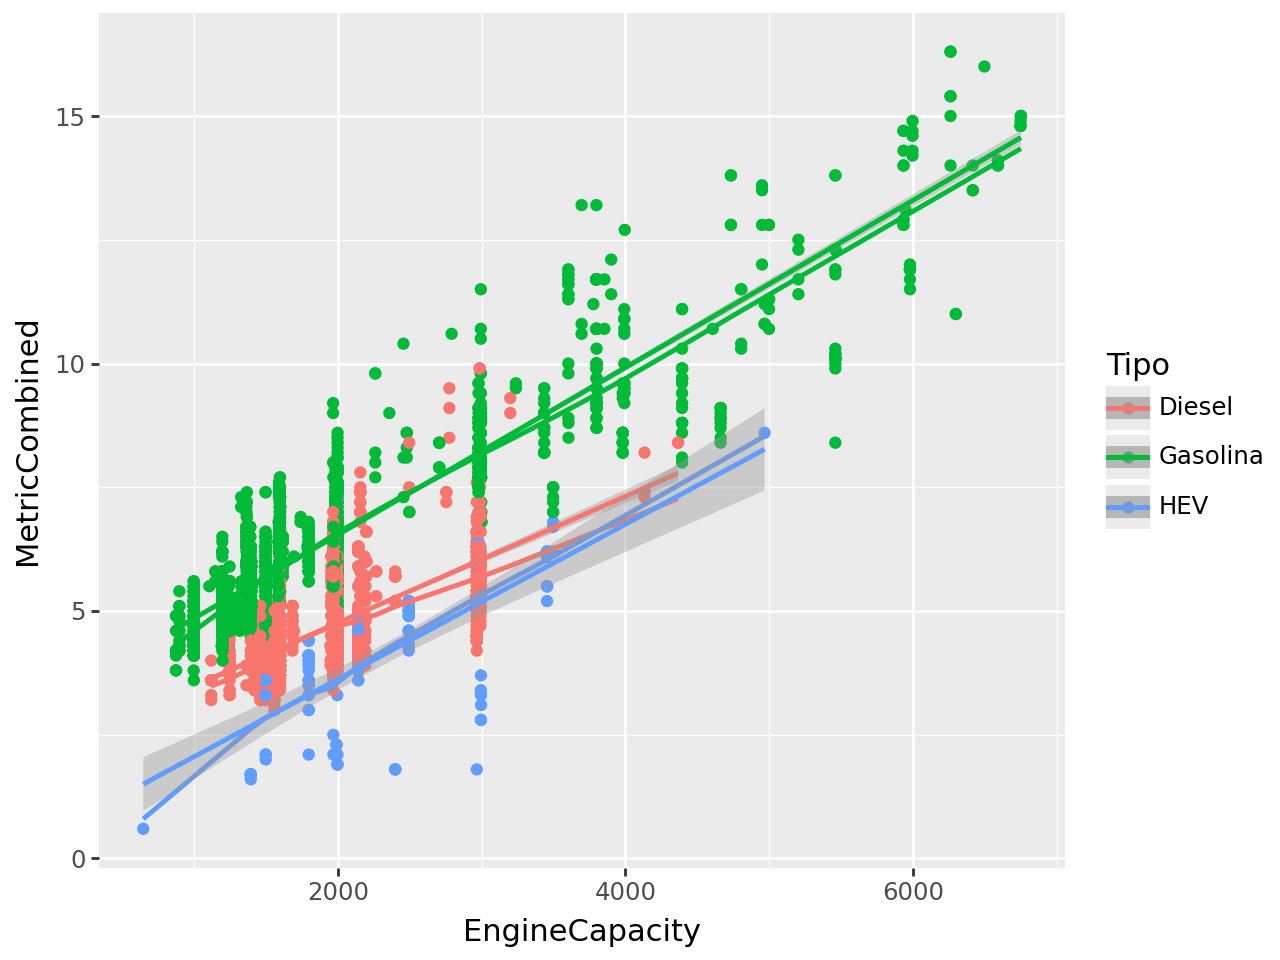

In [17]:
(
    ggplot(df)  # What data to use
    + aes(x = 'EngineCapacity', 
          y = 'MetricCombined'
          ,color = 'Tipo'
         )  # What variable to use
    + geom_point()
    + geom_smooth(method = 'lowess') 
    + geom_smooth(method = 'lm')# Geometric object to use for drawing
)

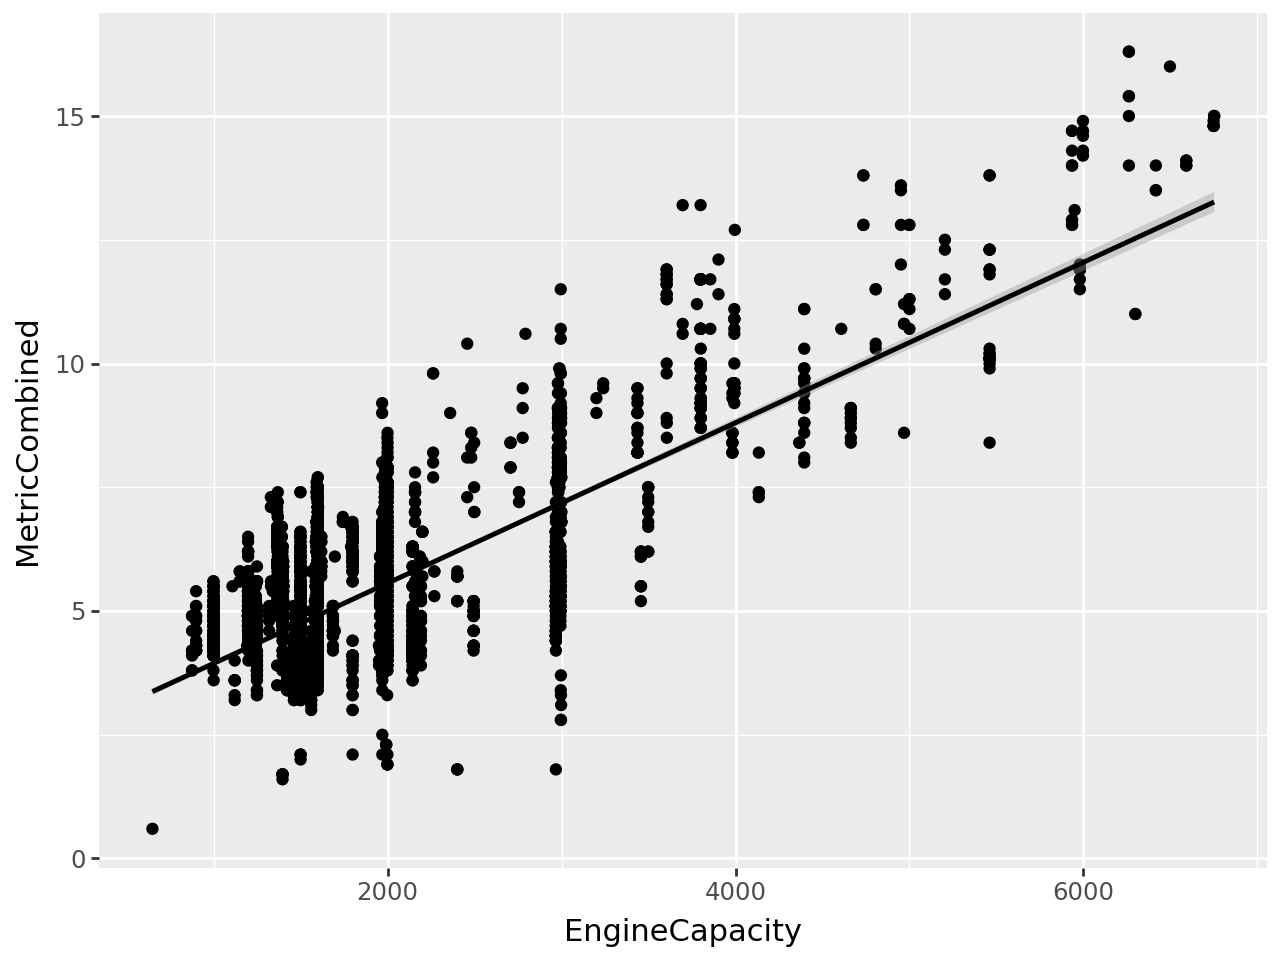

In [18]:
(
    ggplot(df)  # What data to use
    + aes(x = 'EngineCapacity', 
          y = 'MetricCombined')  # What variable to use
    + geom_point()  
    + geom_smooth() # Geometric object to use for drawing
)

In [19]:
g = (
    ggplot(df)  # What data to use
    + aes(x = 'EngineCapacity', 
          y = 'MetricCombined',
         color = 'Tipo')  # What variable to use
    + geom_point()
    + geom_smooth(method = 'lowess') 
    + geom_smooth(method = 'lm') 
)

In [20]:
g = g + theme(figure_size=(12, 12))

In [21]:
g.save("primer_scatterplot.png", dpi = 600)

/home/pedro/Escritorio/UCM_2026/entorno_junio/lib/python3.12/site-packages/plotnine/ggplot.py:623: PlotnineWarning: Saving 12 x 12 in image.
/home/pedro/Escritorio/UCM_2026/entorno_junio/lib/python3.12/site-packages/plotnine/ggplot.py:624: PlotnineWarning: Filename: primer_scatterplot.png
/home/pedro/Escritorio/UCM_2026/entorno_junio/lib/python3.12/site-packages/plotnine/stats/smoothers.py:342: PlotnineWarning: Confidence intervals are not yet implemented for lowess smoothings.


/home/pedro/Escritorio/UCM_2026/entorno_junio/lib/python3.12/site-packages/plotnine/stats/smoothers.py:342: PlotnineWarning: Confidence intervals are not yet implemented for lowess smoothings.


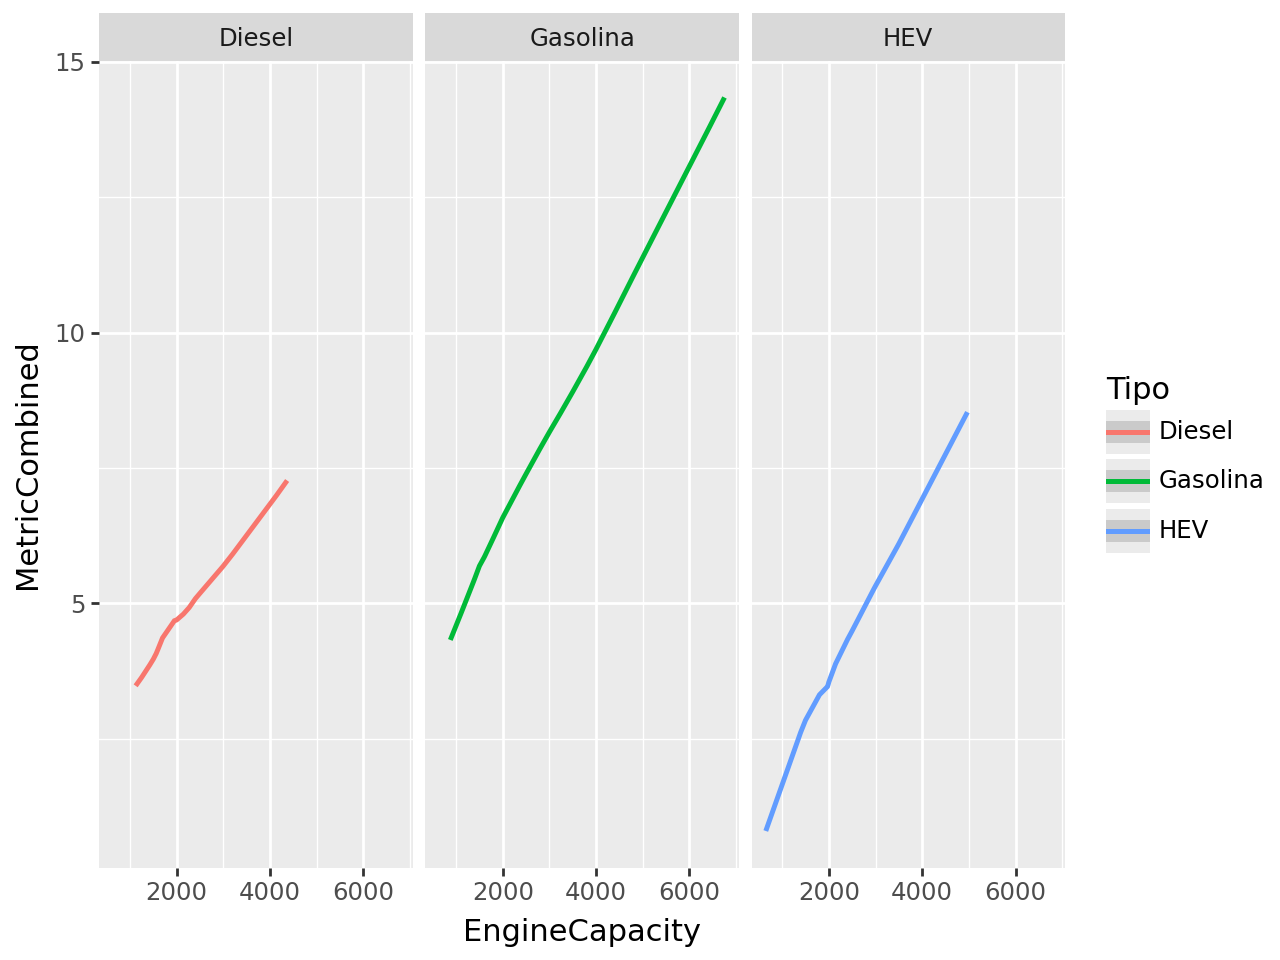

In [22]:
(
    ggplot(df)  # What data to use
    + aes(x = 'EngineCapacity', 
          y = 'MetricCombined',
         color = 'Tipo')  # What variable to use
    + geom_smooth(method = 'lowess')   # Geometric object to use for drawing
    + facet_grid(cols = "Tipo")
)

In [23]:
import skmisc

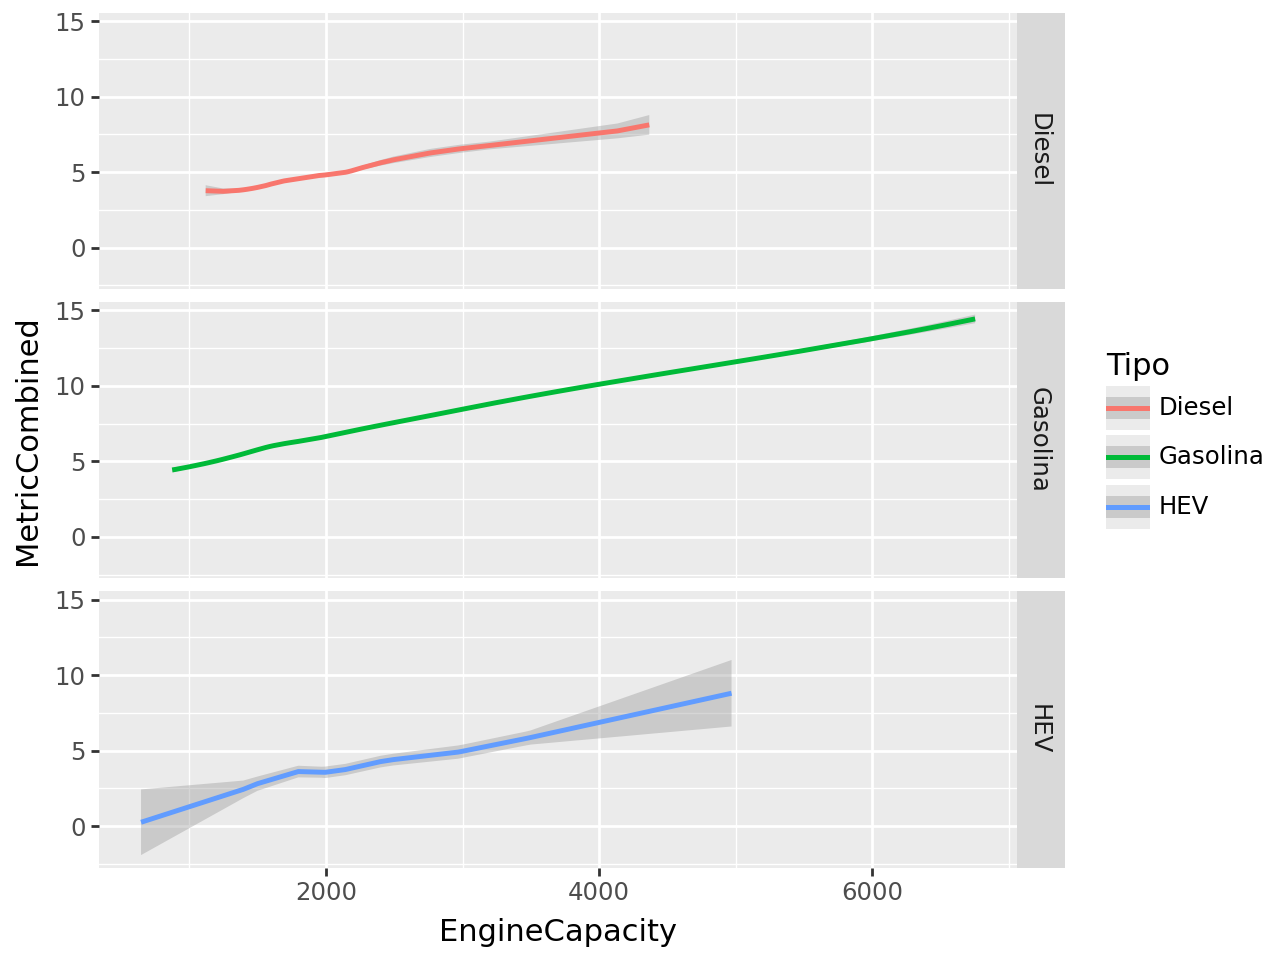

In [24]:
(
    ggplot(df)  # What data to use
    + aes(x = 'EngineCapacity', 
          y = 'MetricCombined',
         color = 'Tipo')  # What variable to use
    + geom_smooth(method = 'loess')   # Geometric object to use for drawing
    + facet_grid(rows = "Tipo")
)

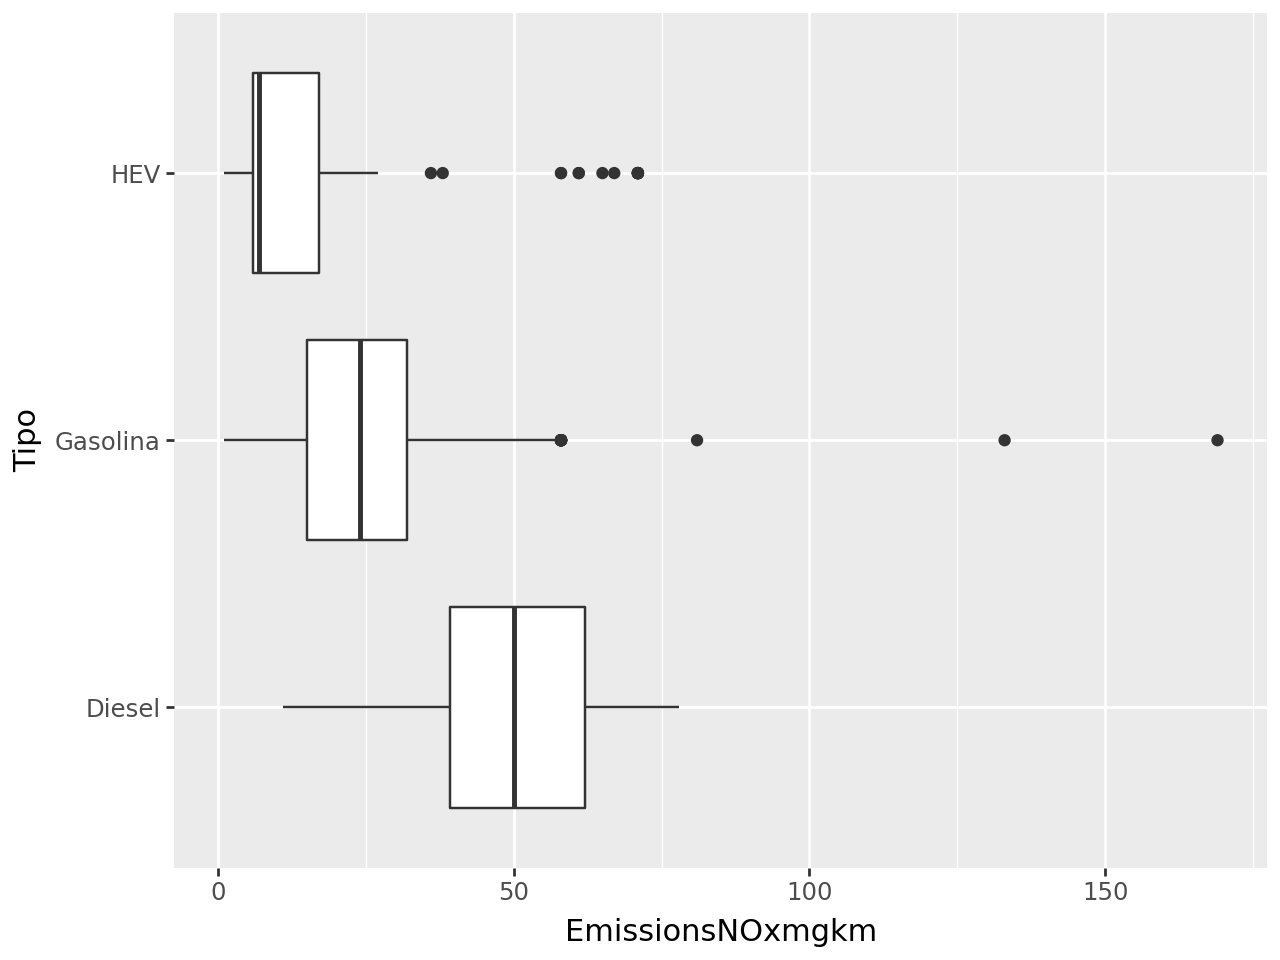

In [25]:
(
    ggplot(df)
    + aes( x = 'Tipo',
         y = "EmissionsNOxmgkm")
    + geom_boxplot()
    + coord_flip() 
#    + theme_classic()
    
)

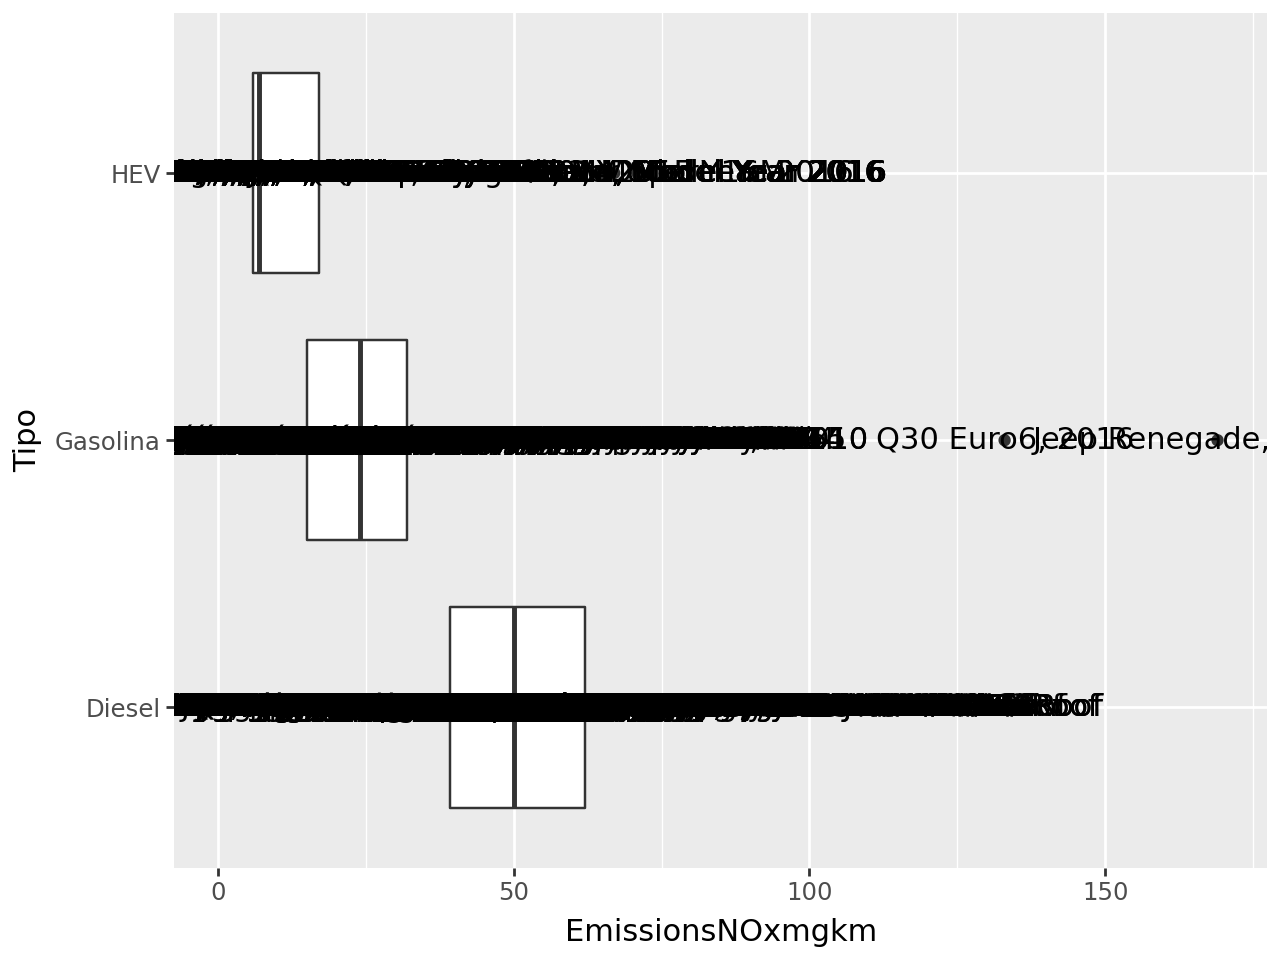

In [26]:
(
    ggplot(df)
    + aes( x = 'Tipo',
         y = "EmissionsNOxmgkm")
    + geom_boxplot()
    + coord_flip() 
    + geom_text(aes(label = "Model"))
    
)

In [27]:
df.dtypes

Manufacturer                str
Model                       str
EngineCapacity            int64
FuelType                    str
MetricUrbanCold         float64
MetricExtraUrban        float64
MetricCombined          float64
ImperialUrbanCold       float64
ImperialExtraUrban      float64
ImperialCombined        float64
CO2gkm                    int64
FuelCost12000Miles        int64
EuroStandard              int64
NoiseLeveldBA           float64
EmissionsCOmgkm         float64
THCEmissionsmgkm        float64
EmissionsNOxmgkm        float64
THC+NOxEmissionsmgkm    float64
ParticulatesNo_mgkm     float64
Tipo                        str
dtype: object

/home/pedro/Escritorio/UCM_2026/entorno_junio/lib/python3.12/site-packages/plotnine/stats/smoothers.py:342: PlotnineWarning: Confidence intervals are not yet implemented for lowess smoothings.


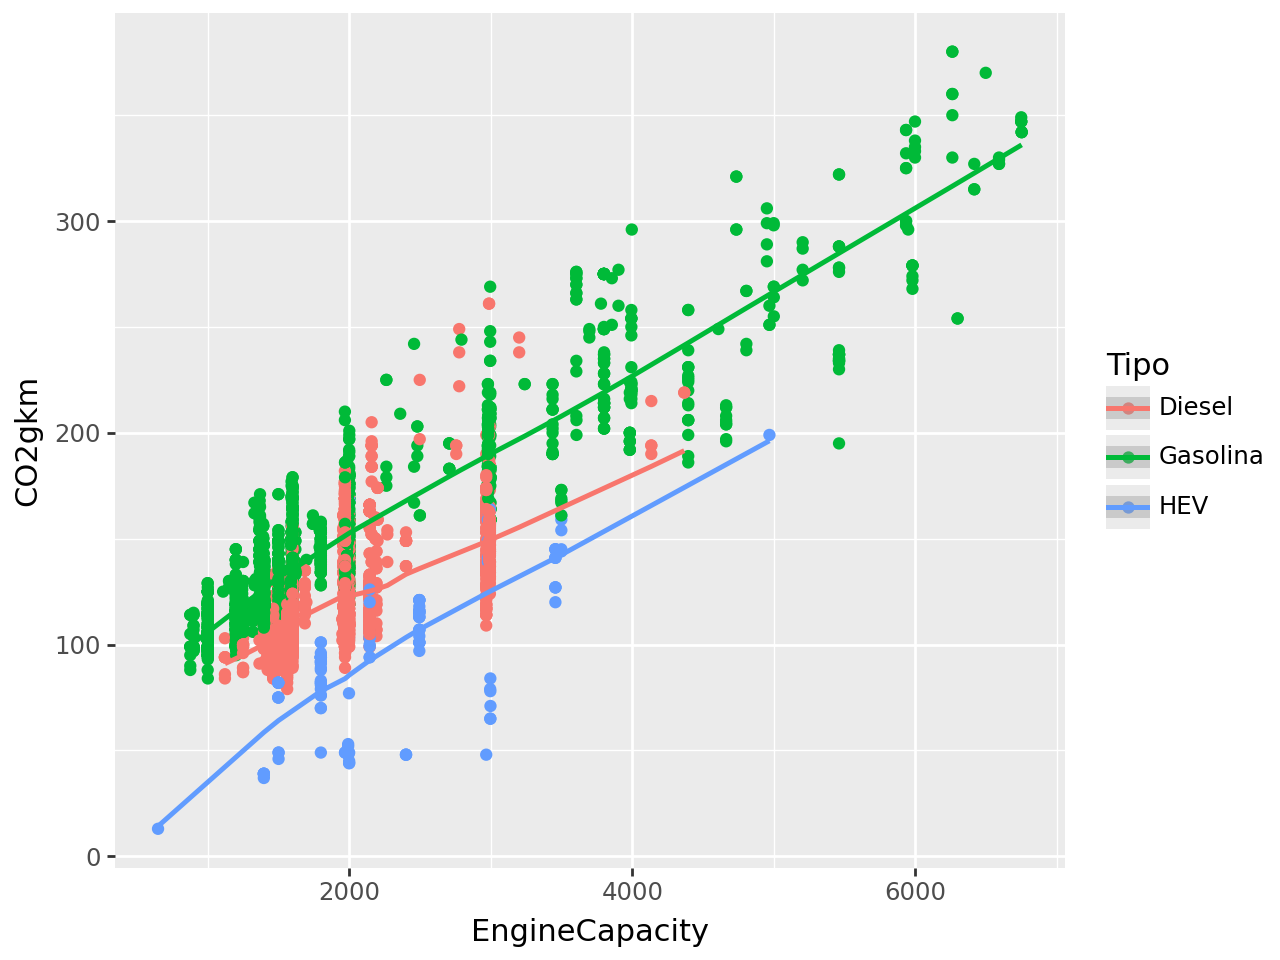

In [28]:
(
    ggplot(df)  # What data to use
    + aes(x = 'EngineCapacity', 
          y = 'CO2gkm',
          color = 'Tipo')  # What variable to use
    + geom_point() 
    + geom_smooth(method = 'lowess')# Geometric object to use for drawing
)